In [2]:
import xarray as xr

file_path = "/home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T061454-2005001T075645-REV06223_vA8.2.0r000.nc"
data = xr.open_dataset(file_path)
file2_path = "/home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T025102-2005001T043253-REV06221_vA8.2.0r000.nc"
data2 = xr.open_dataset(file2_path)
print("数据集属性:")
print(data.attrs)

print("变量列表:")
for var_name in data.variables:
    print(f"  - {var_name}")

# 2. 选择半球（以北半球为例）
# 注意：能量通量图和地磁坐标网格都有明确的北半球变量
energy_flux_map = data['ENERGY_FLUX_NORTH_MAP']          # 形状可能为 (n, m)
geo_lat_grid = data['MODEL_NORTH_GEOGRAPHIC_LATITUDE']   # 形状应与上行一致
geo_lon_grid = data['MODEL_NORTH_GEOGRAPHIC_LONGITUDE']  # 形状应与上行一致
mlat_grid = data['LATITUDE_GEOMAGNETIC_GRID_MAP']
mlon_grid = data['LONGITUDE_GEOMAGNETIC_NORTH_GRID_MAP']
mlt_grid = data['MLT_GRID_MAP']
altitude = data['ALTITUDE']  # 可能是一个标量或一维数组
obs_time = data['TIME']  
data_quality = data['NORTH_DATA_QUALITY']
avg_time = data['TIME'].values.item()
avg_time_2 = data2['TIME'].values.item()

# 4. 检查并确保网格形状匹配（关键步骤）
print(f"能量通量图形状: {energy_flux_map.shape}")
print(f"地理纬度网格形状: {geo_lat_grid.shape}")
print(f"地理经度网格形状: {geo_lon_grid.shape}")
print(f"地磁纬度网格形状: {mlat_grid.shape}")
print(f"地磁经度网格形状: {mlon_grid.shape}")
print(f"地磁时角网格形状: {mlt_grid.shape}")
print(f"平均时间: {avg_time}")
print(data['TIME'].attrs)
#print(data_quality.shape)
print(data_quality.values)
print(f"MLT_GRID_MAP 属性: {data['MLT_GRID_MAP'].attrs}")



数据集属性:
{'MISSION': 'F16', 'DATA_PRODUCT_TYPE': 'EDR AURORA', 'SOURCE': 'SSUSIF16_Av0107r000_2005001REV06223QONA.image_PREP, PS.APL_V0109S027CC0019_SC.U_DI.A_GP.F16-SSUSI_PA.APL-L1B_DD.20050101_SN.06223-00_DF.NC', 'SCAN_TYPE': 'LIMB', 'REGION_TYPE': 'AURORA', 'DATA_PRODUCT_VERSION': '0106', 'DATA_PRODUCT_REVISION': '000', 'DATA_DOCUMENTATION_VERSION': '0124', 'SOFTWARE_VERSION': 'rel_8_2_0', 'SOFTWARE_VERSION_NUMBER': '027', 'SOFTWARE_NAME': 'APL L1B to EDR algorithm X', 'CALIBRATION_TABLES_NAMES': 'SSUSI5_DMSP_F16_CALC_V01R00 Calibration Tables', 'CALIBRATION_TABLES_CREATED': '20170321212346UT', 'CALIBRATION_PERIOD_VERSION': 'C0019', 'DESCRIPTION': 'EDR Imaging Mode Data - Aurora', 'COMMENT': 'No comment', 'HISTORY': 'No revisions', 'DATE_GENERATED': 'Wed Jun 13 16:07:24 2018 UT', 'STARTING_TIME': '2005001061454', 'STOPPING_TIME': '2005001075645', 'STARTING_ORBIT_NUMBER': '06223', 'STOPPING_ORBIT_NUMBER': '06223', 'NODAL_CROSSING_EPOCH': '', 'NODAL_DAY': 1, 'NODAL_MONTH': 1, 'NODAL_YEA

In [1]:
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.image import imread
import cartopy.feature as carfeat
import cartopy.io.shapereader as shpreader
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage
import scipy.interpolate
from datetime import datetime
import os
import math
import aacgmv2
from datetime import timedelta
def convert_datetime64_to_datetime(dt64):
    """将 numpy.datetime64 转换为 datetime.datetime"""
    if dt64 is None:
        return None
    if isinstance(dt64, datetime):
        return dt64
    import pandas as pd
    return pd.Timestamp(dt64).to_pydatetime()

def plot(timestamp, repaired_flux):
    timestamp = convert_datetime64_to_datetime(timestamp)
    lat_coords = np.linspace(50, 90, 80)
    mlt_coords = np.linspace(0.0, 24.0, 96)
    mltN, mlatN = np.meshgrid(mlt_coords, lat_coords)
    mlonN_1D_small = aacgmv2.convert_mlt(mltN[0], timestamp, m2a=True)
    mlonN_1D = np.tile(mlonN_1D_small, mlatN.shape[0])
    mlatN_1D = np.squeeze(mlatN.reshape(np.size(mltN), 1))

    (glatN_1D, glonN_1D, galtN) = aacgmv2.convert_latlon_arr(mlatN_1D, mlonN_1D, 100, timestamp,
                                                                        method_code="A2G")

    # 插值到世界地图网格
    geo_2D = np.vstack((glatN_1D, glonN_1D)).T
    fluxN_1D = repaired_flux.reshape(7680, 1)

    # 创建世界地图网格 - 使用更小的网格
    h, w = 512, 1024
    wx, wy = np.mgrid[-90:90:180 / h, -180:180:360 / w]

    # 线性插值
    aimg = np.squeeze(scipy.interpolate.griddata(geo_2D, fluxN_1D, (wx, wy), method='linear', fill_value=0))

    # 高斯平滑处理
    aimg = scipy.ndimage.gaussian_filter(aimg, sigma=(2, 3), mode='wrap')

    aimg = aimg.astype(np.float32)

    colors = [
            (0.0, 0.0, 0.0),
            (0.0, 0.2, 0.0),
            (0.0, 0.5, 0.0),
            (0.0, 0.8, 0.0),
            (0.5, 1.0, 0.0),
            (1.0, 1.0, 0.0),
            (1.0, 0.6, 0.0),
            (1.0, 0.3, 0.0),
            (1.0, 0.0, 0.0),
        ]
    cmap = LinearSegmentedColormap.from_list('aurora', colors, N=256)
    fig = plt.figure(figsize=(12, 10), dpi=150)
    fig.set_facecolor('black')

    ax = fig.add_subplot(1, 1, 1,
                            projection=ccrs.Orthographic(116.2,
                                                        90),
                            position=[0.3, 0.1, 0.45, 0.45])
    background_img = '/home/docker/data/private/AuroraData/background_img/natural-earth-1_large2048px.png'
    map_img = imread(background_img)
    ax.imshow(map_img, origin='upper', transform=ccrs.PlateCarree(),
                extent=[-180, 180, -90, 90], zorder=0)


    gl = ax.gridlines(linestyle='--', alpha=0.5, color='white')
    gl.n_steps = 100
    gl.xlocator = matplotlib.ticker.FixedLocator(np.arange(-180, 190, 45))
    gl.ylocator = matplotlib.ticker.FixedLocator(np.arange(-90, 100, 10))



    ax.coastlines('10m', color='white', alpha=0.4)


    img = ax.imshow(aimg,
                    vmin=0,
                    vmax=5,
                    transform=ccrs.PlateCarree(),
                    extent=[-180, 180, -90, 90],
                    origin='lower',
                    zorder=3,
                    alpha=0.8,
                    cmap=cmap)


    if timestamp is not None:
        time_str = timestamp.strftime("%Y-%m-%d %H:%M UT")
    else:
        time_str = "Unknown Time"
    title = "DMSP SSUSI Aurora"
    fig.text(0.5, 0.95, f'{title} - {time_str}',
                color='white', fontsize=18, ha='center', weight='bold')

    cbaxes = fig.add_axes([0.3, 0.07, 0.4, 0.02])
    cbar = plt.colorbar(img, cax=cbaxes, orientation='horizontal')
    cbar.set_alpha(1)
    cbar.ax.tick_params(labelsize=15, colors='white')
    cbar.set_label(r'aurora flux $\mathrm{erg\/cm^{-2}\/s^{-1}}$',
                    color='white', fontsize=16)

    plt.tight_layout()
    plt.show()
    #plt.savefig(save_path, dpi=150, facecolor='black')

In [40]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from matplotlib.colors import LinearSegmentedColormap

def extract_and_interpolate(file_path):
    # ----------------------------- 1. 读取数据 -----------------------------
    ds = xr.open_dataset(file_path)
    energy_flux = ds['ENERGY_FLUX_NORTH_MAP'].values  # 形状 (363, 363)
    mlat_orig = ds['LATITUDE_GEOMAGNETIC_GRID_MAP'].values
    mlt_orig = ds['MLT_GRID_MAP'].values
    avg_time = ds['TIME'].values.item()
    year = int(ds['YEAR'].values.item())
    doy = int(ds['DOY'].values.item())
    avg_time_seconds = float(avg_time)
    base_time = datetime(year-1, 12, 31) + timedelta(days=doy)  # 当年第一天
    data_time = base_time + timedelta(seconds=avg_time_seconds)
    
    # ----------------------------- 2. 展平并筛选有效数据 -----------------------------
    # 将网格展平为一维数组，并过滤掉无效值（NaN）
    valid_mask = ~np.isnan(energy_flux) & ~np.isnan(mlat_orig) & ~np.isnan(mlt_orig)
    mlat_points = mlat_orig[valid_mask]
    mlt_points = mlt_orig[valid_mask]
    flux_points = energy_flux[valid_mask]
    

    # ----------------------------- 3. 创建规则的80x96目标网格 -----------------------------
    # 磁纬从50到90度，共80个点
    target_mlat = np.linspace(50, 90, 80)
    # 磁地方时从0到24小时，共96个点（不包括24，因为与0等价）
    target_mlt = np.linspace(0.0, 24.0, 96)

    # 生成网格矩阵
    mlat_grid_2d, mlt_grid_2d = np.meshgrid(target_mlat, target_mlt, indexing='ij')
    # 现在 mlat_grid_2d 和 mlt_grid_2d 都是形状为 (80, 96) 的矩阵

    # ----------------------------- 4. 执行插值（非结构点 -> 规则网格）-------------------------
    # 准备源数据点: 每对 (mlat, mlt) 对应一个 flux 值
    points_source = np.column_stack((mlat_points, mlt_points))
    values_source = flux_points

    # 准备目标网格点: 将 (80, 96) 的网格展平，用于插值计算
    points_target = np.column_stack((mlat_grid_2d.ravel(), mlt_grid_2d.ravel()))
    # 使用线性插值。可选项：'linear'， 'nearest'， 'cubic'
    flux_interpolated = griddata(points_source, values_source, points_target,
                                method='linear', fill_value=np.nan)

    # 将插值结果重塑回 (80, 96) 的二维网格
    flux_grid = flux_interpolated.reshape(mlat_grid_2d.shape)
    flux_grid_filled = np.nan_to_num(flux_grid, nan=0.0)
    
    return flux_grid_filled, data_time

In [ ]:
avg_time_seconds = float(ds['TIME'].values)
base_time = datetime(2005, 1, 1)  # 当年第一天
data_time = base_time + timedelta(seconds=avg_time_seconds)
plot(data_time, flux_grid_filled)

In [3]:
import pandas as pd
folder_path = "/home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005"
save_path = "/home/docker/data/private/AuroraData/process_ssusi"

# data = {
#     'utc':[],
#     'aurora_flux':[]
# }

# os.makedirs(save_path, exist_ok=True)

file_num = 0
qc_num = 0
qc_num_false = 0


for root, dirs, files in os.walk(folder_path):
    for file in files:
        if file.endswith('.nc'):
            full_path = os.path.join(root, file)
            print(f"找到 .nc 文件: {full_path}")
            #flux_grid_filled, data_time = extract_and_interpolate(full_path)
            data = xr.open_dataset(full_path)
            data_quality = data['NORTH_DATA_QUALITY']
            file_num += 1
            if data_quality == 0:
                qc_num += 1
            else:
                qc_num_false += 1
            # data['utc'].append(data_time)
            # data['aurora_flux'].append(flux_grid_filled)

print(file_num)
print(qc_num)
print(qc_num_false)
# df = pd.DataFrame(data)
# df['utc'] = pd.to_datetime(df['utc'])
# df.sort_values(by='utc', inplace=True)
# df.reset_index(drop=True, inplace=True)
# structured_array = df.to_records(index=False)
# np.save(os.path.join(save_path, 'aurora_2005_ssusi.npy'), structured_array)

找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T061454-2005001T075645-REV06223_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T093846-2005001T112037-REV06225_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T112042-2005001T130233-REV06226_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T162630-2005001T180821-REV06229_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T213218-2005001T231409-REV06232_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T010906-2005001T025057-REV06220_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraDat

找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/064/dmspf16_ssusi_edr-aurora_2005064T094301-2005064T112452-REV07115_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/064/dmspf16_ssusi_edr-aurora_2005064T061909-2005064T080100-REV07113_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/064/dmspf16_ssusi_edr-aurora_2005064T144849-2005064T163040-REV07118_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/064/dmspf16_ssusi_edr-aurora_2005064T163045-2005064T181236-REV07119_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/073/dmspf16_ssusi_edr-aurora_2005073T074726-2005073T092917-REV07241_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/073/dmspf16_ssusi_edr-aurora_2005073T175903-2005073T194054-REV07247_vA8.2.0r000.nc
找到 .nc 文件: /home/docker/data/private/AuroraDat

(4841,)
(4841,)
(80, 96)


/tmp/ipykernel_275640/1864976337.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


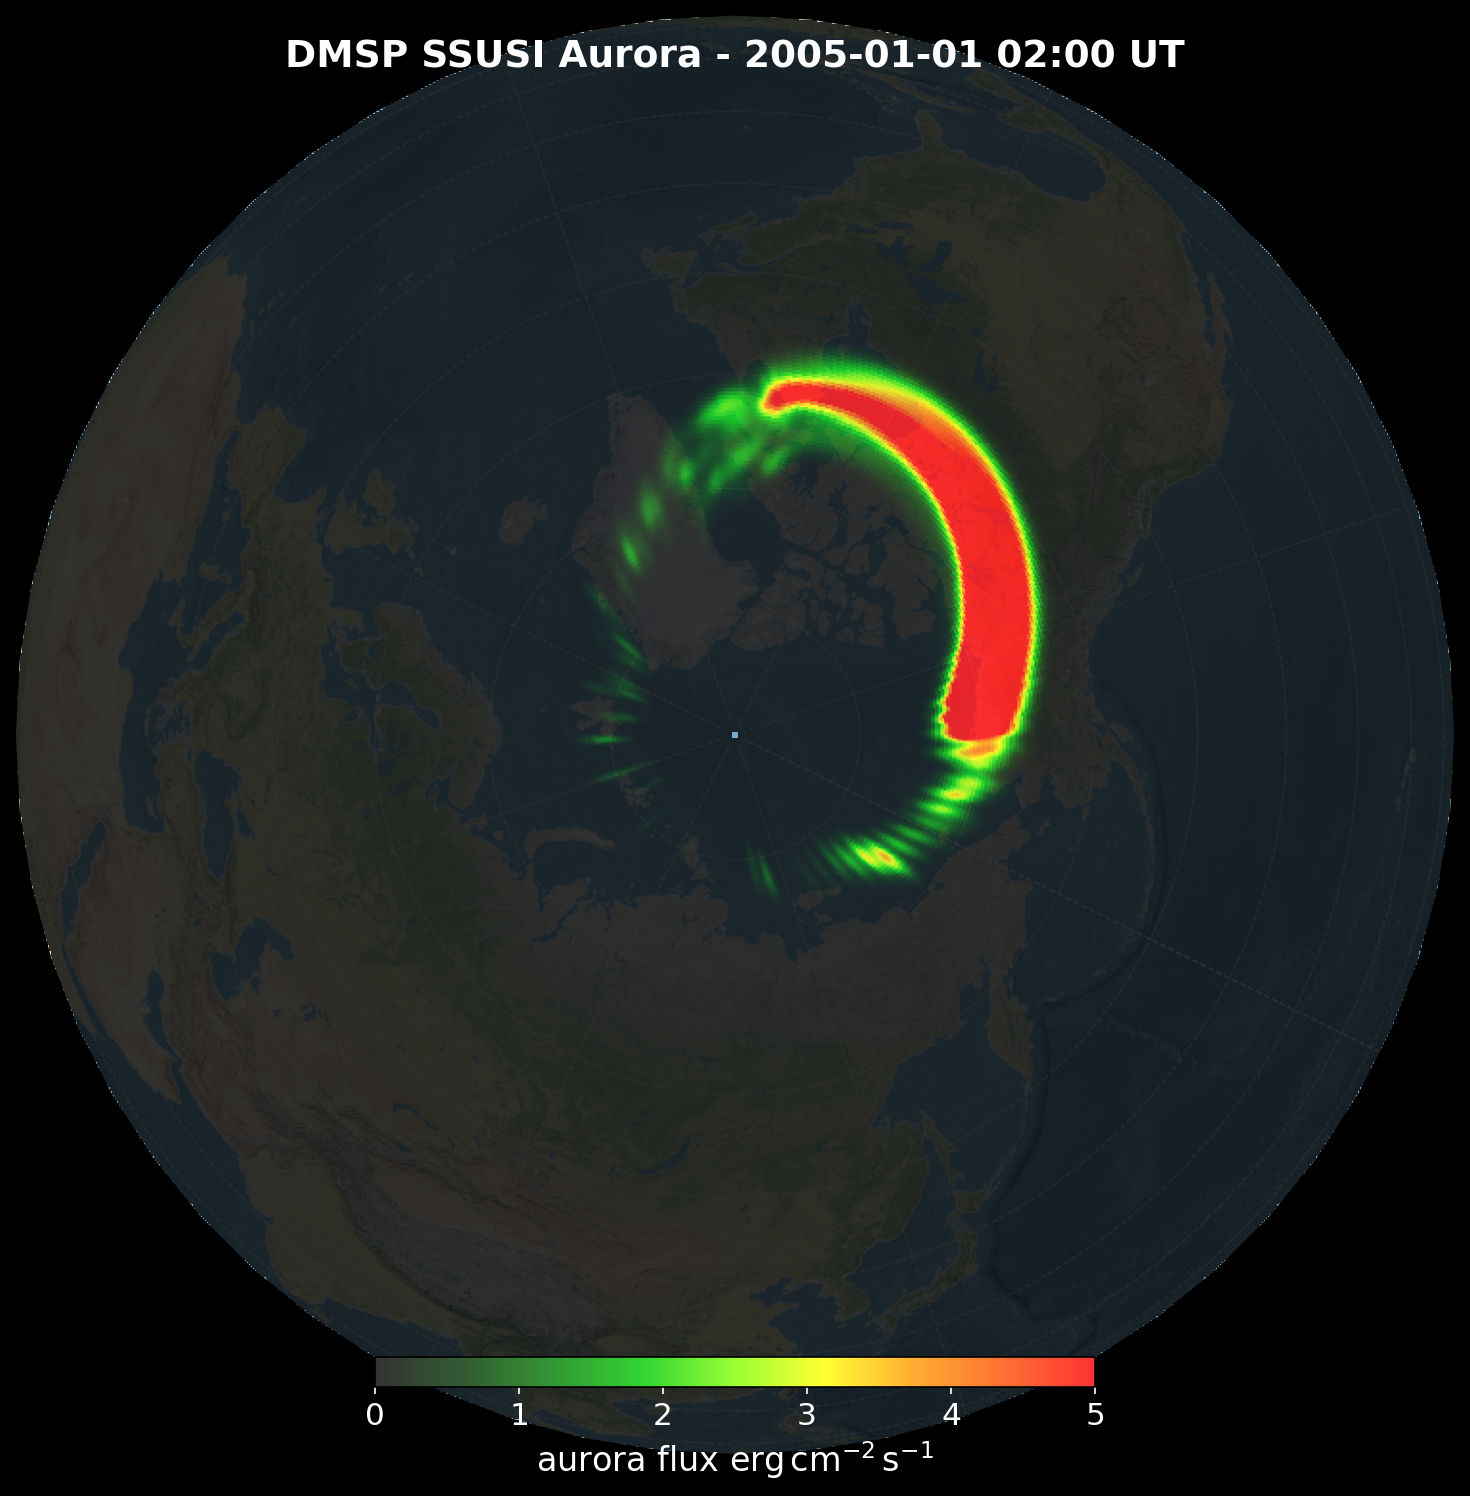

In [21]:
import numpy as np

data = np.load('/home/docker/data/private/AuroraData/process_ssusi/aurora_2005_ssusi.npy', allow_pickle=True)

print(data.shape)
aurora_data = data['aurora_flux']
print(aurora_data.shape)
aurora = aurora_data[0]
print(aurora.shape)
times = data['utc']
time = data['utc'][0]

plot(time, aurora)

/tmp/ipykernel_275640/1864976337.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


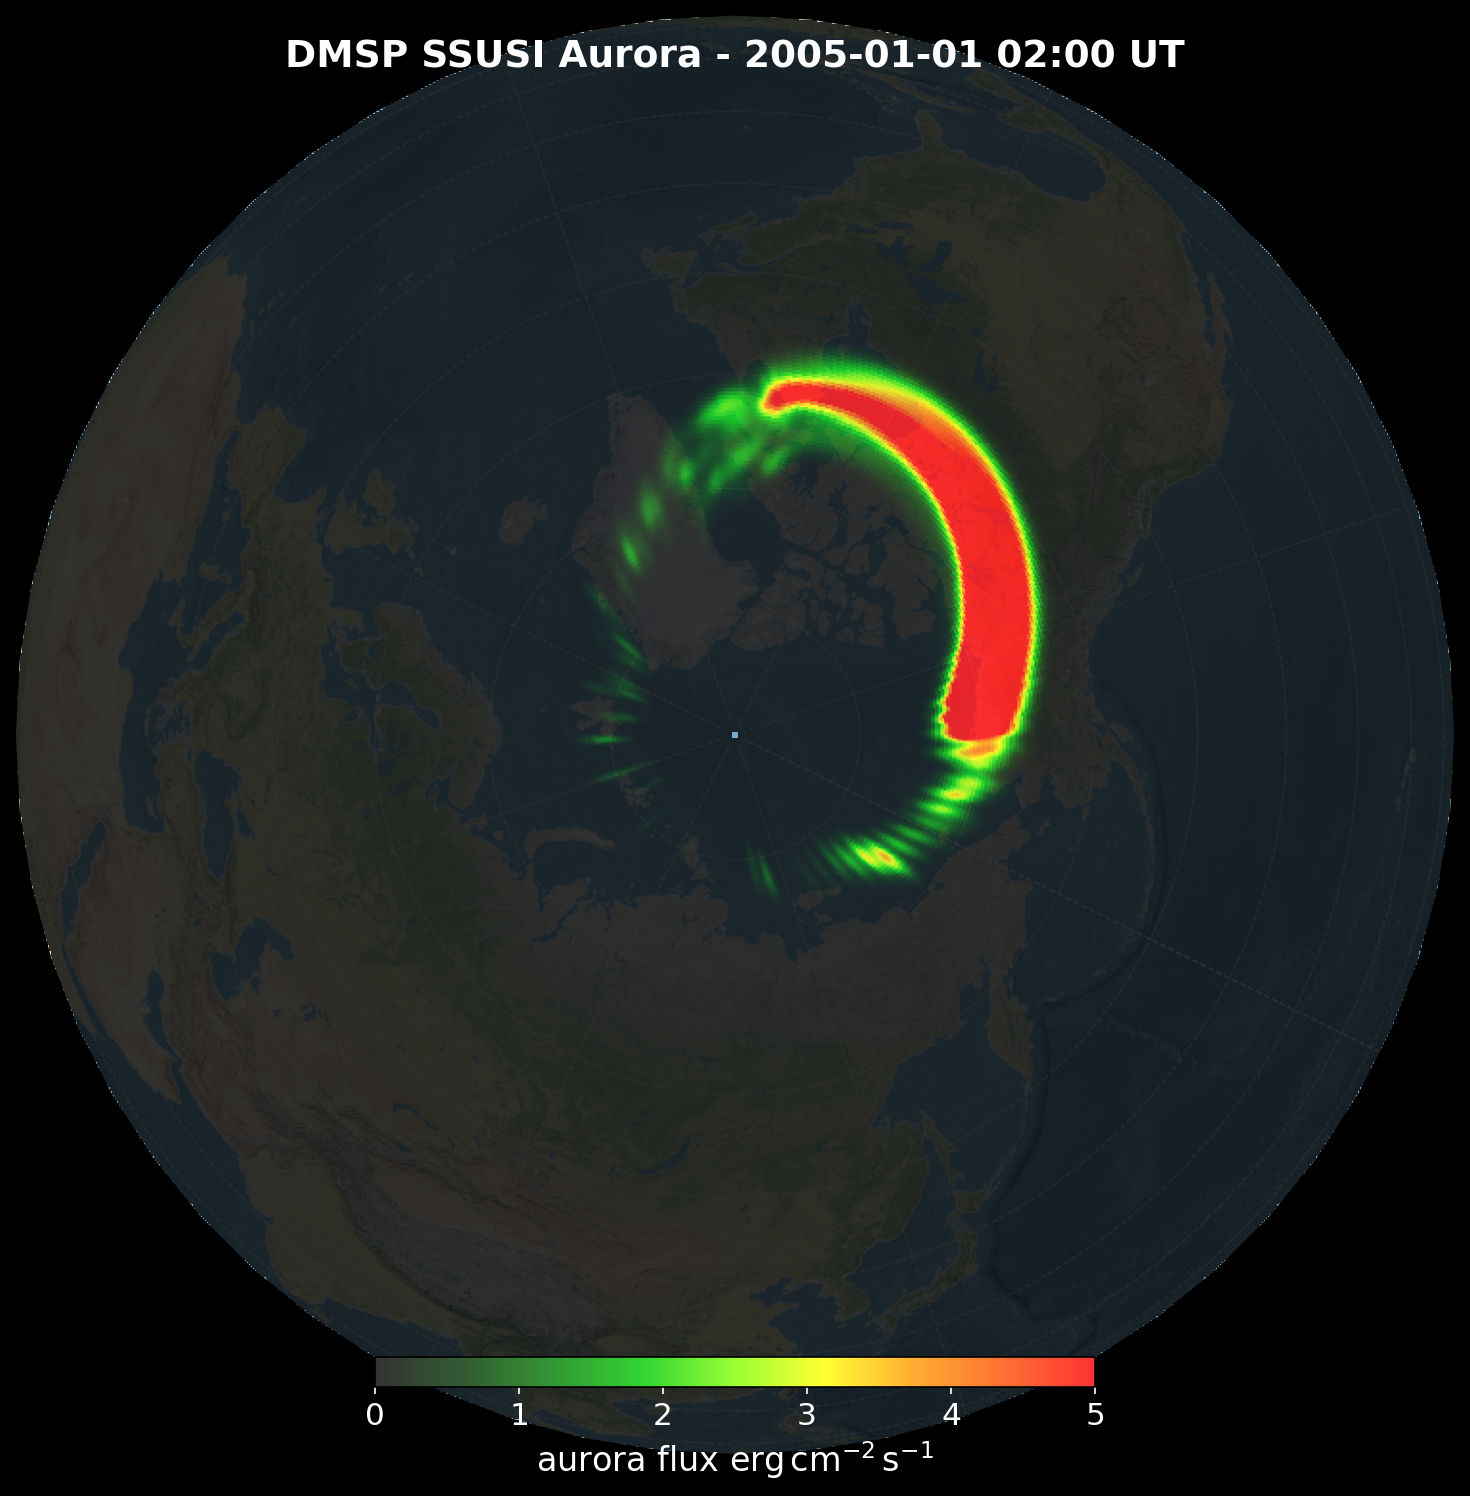

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from matplotlib.colors import LinearSegmentedColormap

file_path = "/home/docker/data/private/AuroraData/real_aurora_data_ssusi/2005/001/dmspf16_ssusi_edr-aurora_2005001T010906-2005001T025057-REV06220_vA8.2.0r000.nc"

# ----------------------------- 1. 读取数据 -----------------------------
ds = xr.open_dataset(file_path)
energy_flux = ds['ENERGY_FLUX_NORTH_MAP'].values  # 形状 (363, 363)
mlat_orig = ds['LATITUDE_GEOMAGNETIC_GRID_MAP'].values
mlon_orig = ds['LONGITUDE_GEOMAGNETIC_NORTH_GRID_MAP'].values
mlt_orig = ds['MLT_GRID_MAP'].values
avg_time = ds['TIME'].values.item()
year = int(ds['YEAR'].values.item())
doy = int(ds['DOY'].values.item())
avg_time_seconds = float(avg_time)
base_time = datetime(year-1, 12, 31) + timedelta(days=doy)  # 当年第一天
data_time = base_time + timedelta(seconds=avg_time_seconds)

# ----------------------------- 2. 展平并筛选有效数据 -----------------------------
# 将网格展平为一维数组，并过滤掉无效值（NaN）
#valid_mask = ~np.isnan(energy_flux) & ~np.isnan(mlat_orig) & ~np.isnan(mlt_orig)
valid_mask = ~np.isnan(energy_flux) & ~np.isnan(mlat_orig) & ~np.isnan(mlon_orig)
mlat_points = mlat_orig[valid_mask]
mlon_points = mlon_orig[valid_mask]
flux_points = energy_flux[valid_mask]

# 将地磁经度 (Mlon) 转换为磁地方时 (MLT)
# 公式: MLT = (Mlon/15.0 + 12) % 24
#mlt_points = (mlon_points / 15.0 + 12) % 24
mlon_shifted = (mlon_points + 180) % 360 - 180
# 使用与您绘图代码匹配的公式
mlt_calculated = (mlon_shifted / 15.0 + 12) % 24
#mlt_calculated = (mlon_points / 15.0 + 12) % 24
#mlt_direct = mlt_orig[valid_mask]

mlt_points = mlt_calculated
# ----------------------------- 3. 创建规则的80x96目标网格 -----------------------------
# 磁纬从50到90度，共80个点
target_mlat = np.linspace(50, 90, 80)
# 磁地方时从0到24小时，共96个点（不包括24，因为与0等价）
target_mlt = np.linspace(0.0, 24.0, 96)

# 生成网格矩阵
mlat_grid_2d, mlt_grid_2d = np.meshgrid(target_mlat, target_mlt, indexing='ij')
# 现在 mlat_grid_2d 和 mlt_grid_2d 都是形状为 (80, 96) 的矩阵

# ----------------------------- 4. 执行插值（非结构点 -> 规则网格）-------------------------
# 准备源数据点: 每对 (mlat, mlt) 对应一个 flux 值
points_source = np.column_stack((mlat_points, mlt_points))
values_source = flux_points

# 准备目标网格点: 将 (80, 96) 的网格展平，用于插值计算
points_target = np.column_stack((mlat_grid_2d.ravel(), mlt_grid_2d.ravel()))
# 使用线性插值。可选项：'linear'， 'nearest'， 'cubic'
flux_interpolated = griddata(points_source, values_source, points_target,
                            method='linear', fill_value=np.nan)

# 将插值结果重塑回 (80, 96) 的二维网格
flux_grid = flux_interpolated.reshape(mlat_grid_2d.shape)
flux_grid_filled = np.nan_to_num(flux_grid, nan=0.0)


plot(data_time, flux_grid_filled)

In [11]:
import numpy as np
import xarray as xr

# 1. 读取数据
ds = xr.open_dataset(file_path)
energy_flux = ds['ENERGY_FLUX_NORTH_MAP'].values
mlat_orig = ds['LATITUDE_GEOMAGNETIC_GRID_MAP'].values
mlon_orig = ds['LONGITUDE_GEOMAGNETIC_NORTH_GRID_MAP'].values
mlt_orig = ds['MLT_GRID_MAP'].values

# 2. 定义两种掩码
mask_A = ~np.isnan(energy_flux) & ~np.isnan(mlat_orig) & ~np.isnan(mlon_orig)
mask_B = ~np.isnan(energy_flux) & ~np.isnan(mlat_orig) & ~np.isnan(mlt_orig)

print(f"有效点数量统计:")
print(f"  方法A (依赖 MLON) 有效点: {np.sum(mask_A)}")
print(f"  方法B (依赖 MLT) 有效点: {np.sum(mask_B)}")
print(f"  两者的共同有效点 (交集): {np.sum(mask_A & mask_B)}")
print(f"  仅方法A有效: {np.sum(mask_A & ~mask_B)}")
print(f"  仅方法B有效: {np.sum(~mask_A & mask_B)}")

# 3. 在“交集”点位上比较MLT值
common_mask = mask_A & mask_B
if np.sum(common_mask) > 0:
    mlon_common = mlon_orig[common_mask]
    mlt_direct_common = mlt_orig[common_mask]
    mlt_calc_common = (mlon_common / 15.0 + 12) % 24
    
    diff = mlt_direct_common - mlt_calc_common
    print(f"\n在 {np.sum(common_mask)} 个共同有效点上比较MLT:")
    print(f"  直接读取的MLT范围: [{mlt_direct_common.min():.2f}, {mlt_direct_common.max():.2f}]")
    print(f"  经度换算的MLT范围: [{mlt_calc_common.min():.2f}, {mlt_calc_common.max():.2f}]")
    print(f"  平均绝对差值: {np.nanmean(np.abs(diff)):.6f} 小时")
else:
    print("\n警告：两种方法没有共同的有效点！这说明坐标数据不一致。")
# 4. 深入检查MLON数据与偏差规律
print(f"\n深入诊断：")
print(f"  原始 MLON 值范围: [{mlon_orig.min():.1f}, {mlon_orig.max():.1f}]")
# 检查MLON是否有异常（如全在0-360， 或-180-180）
print(f"  MLON 中位数: {np.nanmedian(mlon_orig):.1f}")

# 5. 查看MLT网格的官方属性（可能包含定义说明）
print(f"\nMLT_GRID_MAP 变量的属性:")
print(ds['MLT_GRID_MAP'].attrs) # 重点查看 'units', 'long_name', 'description' 等字段

# 6. 抽样查看具体点的差异（例如前10个共同有效点）
sample_idx = np.where(common_mask)[0][:10]
print(f"\n抽样点详细对比 (索引 -> MLAT, MLON, MLT_直接, MLT_计算):")
for idx in sample_idx:
    print(f"  {idx}: {mlat_orig.flat[idx]:5.1f}, {mlon_orig.flat[idx]:7.2f}, {mlt_orig.flat[idx]:6.2f}, {(mlon_orig.flat[idx]/15+12)%24:6.2f}")

有效点数量统计:
  方法A (依赖 MLON) 有效点: 131769
  方法B (依赖 MLT) 有效点: 131769
  两者的共同有效点 (交集): 131769
  仅方法A有效: 0
  仅方法B有效: 0

在 131769 个共同有效点上比较MLT:
  直接读取的MLT范围: [0.02, 24.00]
  经度换算的MLT范围: [0.00, 24.00]
  平均绝对差值: 7.536908 小时

深入诊断：
  原始 MLON 值范围: [0.0, 360.0]
  MLON 中位数: 0.0

MLT_GRID_MAP 变量的属性:
{'TITLE': 'Magnetic local time grid map', 'UNITS': 'hours'}

抽样点详细对比 (索引 -> MLAT, MLON, MLT_直接, MLT_计算):
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
  0:  33.4,    0.00,  21.00,  12.00
